<a href="https://colab.research.google.com/github/Ananyaya17/Hindi-Image-Captioning-/blob/main/BLIP%20%2B%20LoRA%20%2B%20Hindi%20projection%20head.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Install Dependencies
# After running: RESTART RUNTIME, then run from Cell 2.
# Do NOT re-run Cell 1 after restarting.
# ============================================================

!pip install -q "transformers>=4.41.0,<6.0.0"
!pip install -q torch torchvision
!pip install -q peft
!pip install -q nltk Pillow tqdm matplotlib accelerate

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All dependencies installed.")
print("RESTART RUNTIME NOW, then run from Cell 2.")


All dependencies installed.
RESTART RUNTIME NOW, then run from Cell 2.


In [ ]:
# ============================================================
# CELL 2 — Imports + Device Setup
# ============================================================

import os, json, random, pickle, shutil, zipfile, textwrap, re, unicodedata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Prevents memory fragmentation OOM on T4
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_GPU   = torch.cuda.is_available()
AMP_DTYPE = torch.float16 if USE_GPU else torch.bfloat16

if USE_GPU:
    torch.cuda.manual_seed_all(SEED)
    print(f"✅ GPU:  {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")

print(f"Device: {device}")


✅ GPU:  Tesla T4
   VRAM: 15.6 GB
Device: cuda


In [ ]:
# ============================================================
# CELL 3 — Mount Drive + Extract Dataset
# (Identical to your working notebook — no changes needed)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

zip_path     = '/content/drive/MyDrive/data.zip'
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

if not os.path.exists(zip_path):
    raise FileNotFoundError("data.zip not found at /content/drive/MyDrive/data.zip")

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete")

archive_path = os.path.join(extract_path, 'archive (1)')
if os.path.exists(archive_path):
    images_src   = os.path.join(archive_path, 'Images_all')
    captions_src = os.path.join(archive_path, 'Clean-5Sentences_withComma.txt')
    images_dst   = os.path.join(extract_path, 'Images_all')
    captions_dst = os.path.join(extract_path, 'captions.txt')

    if os.path.exists(images_src):
        if os.path.exists(images_dst): shutil.rmtree(images_dst)
        shutil.move(images_src, images_dst)
        print("Images moved")

    if os.path.exists(captions_src):
        if os.path.exists(captions_dst): os.remove(captions_dst)
        shutil.move(captions_src, captions_dst)
        print("Captions moved")

    shutil.rmtree(archive_path)
    print("Archive cleaned up")

IMAGES_DIR     = os.path.join(extract_path, 'Images_all')
CAPTIONS_FILE  = os.path.join(extract_path, 'captions.txt')
CHECKPOINT_DIR = '/content/drive/MyDrive/blip_lora_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

assert os.path.isdir(IMAGES_DIR),     f"Images folder not found: {IMAGES_DIR}"
assert os.path.isfile(CAPTIONS_FILE), f"Captions file not found: {CAPTIONS_FILE}"

img_count = len([f for f in os.listdir(IMAGES_DIR)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
print(f"\n✅ Images found:  {img_count}")
print(f"✅ Checkpoints → {CHECKPOINT_DIR}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting dataset...
Extraction complete
Images moved
Captions moved
Archive cleaned up

✅ Images found:  8091
✅ Checkpoints → /content/drive/MyDrive/blip_lora_checkpoints


In [ ]:
# ============================================================
# CELL 4 — Load and Parse Captions
# (Same cleaning as your notebook)
# ============================================================

def clean_hindi_caption(caption):
    caption = unicodedata.normalize('NFC', caption)
    caption = re.sub(r'[।,.!?"\'\-]', '', caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption

def load_captions(captions_file):
    captions = defaultdict(list)
    with open(captions_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or ',' not in line:
                continue
            img, cap = line.split(',', 1)
            img = img.strip()
            cap = cap.strip()
            if not img.lower().endswith(('.jpg','.jpeg','.png')):
                img = img + '.jpg'
            cap = clean_hindi_caption(cap)
            if cap:
                captions[img].append(cap)
    return dict(captions)

all_captions = load_captions(CAPTIONS_FILE)
all_captions = {img: caps for img, caps in all_captions.items()
                if os.path.isfile(os.path.join(IMAGES_DIR, img))}

print(f"Unique images:  {len(all_captions)}")
print(f"Total captions: {sum(len(v) for v in all_captions.values())}")

sample_img = list(all_captions.keys())[0]
print(f"\nSample — {sample_img}:")
for cap in all_captions[sample_img][:2]:
    print(f"  {cap}")


Unique images:  8090
Total captions: 40450

Sample — 1000268201_693b08cb0e.jpg:
  गुलाबी पोशाक में बच्चा प्रवेश के रास्ते में सीढ़ियों के सेट पर चढ़ रहा है
  लड़की लकड़ी की इमारत में जा रही है


In [ ]:
# ============================================================
# CELL 5 — Train / Val / Test Split  (80 / 10 / 10)
# ============================================================

all_images = list(all_captions.keys())
random.seed(42); random.shuffle(all_images)

n          = len(all_images)
train_imgs = all_images[:int(0.80 * n)]
val_imgs   = all_images[int(0.80 * n):int(0.90 * n)]
test_imgs  = all_images[int(0.90 * n):]

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

with open("/content/splits.json", "w") as f:
    json.dump({"train": train_imgs, "val": val_imgs, "test": test_imgs}, f)


Train: 6472 | Val: 809 | Test: 809


In [ ]:
# ============================================================
# FIXED CELL 6 — Dataset with Hindi prompt prefix
# KEY FIX: prepend "इस तस्वीर में" to EVERY caption during training
# This teaches the model that this prefix → Hindi output
# ============================================================

class Flickr8kHindiDataset(Dataset):
    def __init__(self, image_names, captions_dict,
                 images_dir, processor, max_caption_length=64, augment=False):
        self.images_dir = images_dir
        self.processor  = processor
        self.max_length = max_caption_length
        self.augment    = augment
        self.samples    = [
            (img, cap)
            for img in image_names
            for cap in captions_dict.get(img, [])
            if cap.strip()
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, caption = self.samples[idx]
        image = Image.open(
            os.path.join(self.images_dir, img_name)
        ).convert('RGB')

        if self.augment:
            import torchvision.transforms.functional as TF
            if random.random() > 0.5:
                image = TF.hflip(image)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, random.uniform(0.85, 1.15))

        # KEY FIX: prepend Hindi prompt to caption during training
        # Model learns: image + "इस तस्वीर में" → rest of Hindi caption
        prompted_caption = "इस तस्वीर में " + caption

        enc = self.processor(
            images=image,
            text=prompted_caption,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True
        )
        return {
            'pixel_values':   enc['pixel_values'].squeeze(0),
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
        }


MAX_CAPTION_LEN = 64
BATCH_SIZE      = 4
NUM_WORKERS     = 2
PIN             = USE_GPU

print("Loading BLIP processor...")
processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')

train_dataset = Flickr8kHindiDataset(train_imgs, all_captions, IMAGES_DIR,
                                      processor, MAX_CAPTION_LEN, augment=True)
val_dataset   = Flickr8kHindiDataset(val_imgs,   all_captions, IMAGES_DIR,
                                      processor, MAX_CAPTION_LEN, augment=False)
test_dataset  = Flickr8kHindiDataset(test_imgs,  all_captions, IMAGES_DIR,
                                      processor, MAX_CAPTION_LEN, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN)

print(f"Train samples: {len(train_dataset)} | batches: {len(train_loader)}")
print(f"Val   samples: {len(val_dataset)}   | batches: {len(val_loader)}")
print(f"Batch size: {BATCH_SIZE}")

# Verify prompt is working
sample = train_dataset[0]
print(f"\nSample caption with prompt:")
print(f"  {processor.decode(sample['input_ids'], skip_special_tokens=True)}")


Loading BLIP processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Train samples: 32360 | batches: 8090
Val   samples: 4045   | batches: 1012
Batch size: 4

Sample caption with prompt:
  तसवीर म गलाबी रग की लडकी बिसतर पर ह


In [ ]:
# ============================================================
# FIXED CELL 7 — Load BLIP + LoRA (unchanged from before)
# NEW CHECKPOINT DIR to avoid mixing with old bad checkpoints
# ============================================================

if USE_GPU:
    torch.cuda.empty_cache()

print("Loading BLIP base model...")
base_model = BlipForConditionalGeneration.from_pretrained(
    'Salesforce/blip-image-captioning-base'
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model = model.to(device)

hidden_size = base_model.config.text_config.hidden_size
vocab_size  = base_model.config.text_config.vocab_size

class HindiProjectionHead(nn.Module):
    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.ln1  = nn.LayerNorm(hidden_size)
        self.fc1  = nn.Linear(hidden_size, 512)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(0.1)
        self.ln2  = nn.LayerNorm(512)
        self.fc2  = nn.Linear(512, vocab_size)

    def forward(self, x):
        x = self.ln1(x); x = self.fc1(x); x = self.act(x)
        x = self.drop(x); x = self.ln2(x)
        return self.fc2(x)

hindi_head = HindiProjectionHead(hidden_size, vocab_size).to(device)

# NEW checkpoint dir — clean slate, don't mix with previous run
CHECKPOINT_DIR = '/content/drive/MyDrive/blip_lora_v2_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

total_blip  = sum(p.numel() for p in model.parameters())
lora_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
head_params = sum(p.numel() for p in hindi_head.parameters())

print(f"\n✅ Architecture:")
print(f"   LoRA trainable: {lora_params/1e6:.2f}M")
print(f"   Hindi head:     {head_params/1e3:.0f}K")
print(f"   Checkpoints → {CHECKPOINT_DIR}")



Loading BLIP base model...


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '429 Too Many Requests' for url 'https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/429

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safe

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


✅ Architecture:
   LoRA trainable: 1.18M
   Hindi head:     16055K
   Checkpoints → /content/drive/MyDrive/blip_lora_v2_checkpoints


In [ ]:
# ============================================================
# FIXED CELL 8 — Training functions
# KEY FIX: use model's OWN loss (outputs.loss) during training
# not our custom head loss — this ensures generate() and
# training are aligned (both use the same LM head)
# Hindi head is used as AUXILIARY loss for better gradients
# ============================================================

scaler = torch.amp.GradScaler('cuda', enabled=USE_GPU)

def forward_combined_loss(model, hindi_head, batch, aux_weight=0.0):
    pixel_values   = batch['pixel_values'].to(device)
    input_ids      = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    outputs = model(
        pixel_values=pixel_values,
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=input_ids,
        return_dict=True,
    )
    return outputs.loss

def train_one_epoch(model, hindi_head, loader, optimizer, scheduler):
    model.train(); hindi_head.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc='Training', leave=False)

    for batch in pbar:
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE):
            loss = forward_combined_loss(model, hindi_head, batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(hindi_head.parameters()), 1.0
        )
        scaler.step(optimizer); scaler.update()
        scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


def evaluate_loss(model, hindi_head, loader):
    model.eval(); hindi_head.eval()
    total_loss = 0.0
    if USE_GPU: torch.cuda.empty_cache()

    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation', leave=False):
            with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE):
                loss = forward_combined_loss(model, hindi_head, batch)
            total_loss += loss.item()

    if USE_GPU: torch.cuda.empty_cache()
    return total_loss / len(loader)


def generate_caption_hindi(model, processor, image_path,
                            num_beams=5, max_length=64):
    """
    Uses the same Hindi prompt prefix used during training.
    Training/inference alignment is now guaranteed.
    """
    model.eval()
    try:
        image = Image.open(image_path).convert('RGB')
    except:
        return ""

    inputs = processor(
        images=image,
        text="इस तस्वीर में",   # same prefix as training
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            pixel_values=inputs['pixel_values'],
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            num_beams=num_beams,
            max_length=max_length,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0,
        )

    return processor.decode(out[0], skip_special_tokens=True).strip()


def save_checkpoint(epoch, stage, model, hindi_head, optimizer, history, is_best=False):
    ckpt = {
        'epoch':      epoch,
        'stage':      stage,
        'head_state': hindi_head.state_dict(),
        'optim':      optimizer.state_dict(),
        'history':    history,
    }
    latest_path = os.path.join(CHECKPOINT_DIR, f'stage{stage}_latest.pt')
    torch.save(ckpt, latest_path)

    if is_best:
        model.save_pretrained(os.path.join(CHECKPOINT_DIR, f'stage{stage}_best'))
        processor.save_pretrained(os.path.join(CHECKPOINT_DIR, f'stage{stage}_best'))
        torch.save(hindi_head.state_dict(),
                   os.path.join(CHECKPOINT_DIR, f'stage{stage}_best_head.pt'))
        print(f"  💾 Best saved (epoch {epoch}, stage {stage})")
    else:
        print(f"  💾 Latest saved (epoch {epoch})")


def compute_bleu_scores_hindi(model, processor, image_names,
                               captions_dict, images_dir,
                               num_beams=5, max_samples=500):
    model.eval()
    if USE_GPU: torch.cuda.empty_cache()

    samples        = random.sample(image_names, min(max_samples, len(image_names)))
    references_all = []
    hypotheses_all = []

    for img_name in tqdm(samples, desc='Computing BLEU'):
        img_path = os.path.join(images_dir, img_name)
        if not os.path.isfile(img_path): continue
        hyp  = generate_caption_hindi(model, processor, img_path, num_beams=num_beams)
        refs = [r.strip().split() for r in captions_dict.get(img_name, []) if r.strip()]
        if refs and hyp.strip():
            references_all.append(refs)
            hypotheses_all.append(hyp.strip().split())

    if not hypotheses_all:
        print("No valid predictions."); return {}

    sf = SmoothingFunction().method1
    return {
        'BLEU-1': round(corpus_bleu(references_all, hypotheses_all,
                                    weights=(1,0,0,0), smoothing_function=sf), 4),
        'BLEU-2': round(corpus_bleu(references_all, hypotheses_all,
                                    weights=(.5,.5,0,0), smoothing_function=sf), 4),
        'BLEU-3': round(corpus_bleu(references_all, hypotheses_all,
                                    weights=(.33,.33,.33,0), smoothing_function=sf), 4),
        'BLEU-4': round(corpus_bleu(references_all, hypotheses_all,
                                    weights=(.25,.25,.25,.25), smoothing_function=sf), 4),
        'num_evaluated': len(hypotheses_all),
    }

print("✅ All functions defined.")



✅ All functions defined.


In [ ]:
# ============================================================
# FIXED CELL 9 — Stage 1: 5 epochs (was 3 — too few for Hindi)
# ============================================================

STAGE1_EPOCHS = 5          # increased from 3
STAGE1_LR     = 3e-4       # slightly lower for stability

for name, param in model.named_parameters():
    if 'vision_model' in name:
        param.requires_grad = False

trainable_s1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Stage 1 — trainable: {trainable_s1/1e6:.2f}M (LoRA + Hindi head)")

optimizer_s1 = AdamW(
    [{'params': [p for p in model.parameters() if p.requires_grad], 'lr': STAGE1_LR},
     {'params': hindi_head.parameters(), 'lr': STAGE1_LR}],
    weight_decay=0.01
)
total_steps_s1 = len(train_loader) * STAGE1_EPOCHS
scheduler_s1   = get_linear_schedule_with_warmup(
    optimizer_s1,
    num_warmup_steps  = max(1, total_steps_s1 // 10),
    num_training_steps= total_steps_s1
)

history          = {'train_loss': [], 'val_loss': []}
best_val_loss_s1 = float('inf')

print(f"\nStarting Stage 1 ({STAGE1_EPOCHS} epochs)...")
print("=" * 55)

for epoch in range(1, STAGE1_EPOCHS + 1):
    train_loss = train_one_epoch(model, hindi_head, train_loader,
                                  optimizer_s1, scheduler_s1)
    if USE_GPU: torch.cuda.empty_cache()
    val_loss   = evaluate_loss(model, hindi_head, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    is_best = val_loss < best_val_loss_s1
    if is_best: best_val_loss_s1 = val_loss

    print(f"Epoch {epoch}/{STAGE1_EPOCHS} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f}"
          + (" ⭐ best" if is_best else ""))

    # Quick qualitative check every 2 epochs
    if epoch % 2 == 0:
        sample_img = os.path.join(IMAGES_DIR, test_imgs[0])
        cap = generate_caption_hindi(model, processor, sample_img)
        print(f"  Sample: {cap}")

    save_checkpoint(epoch, 1, model, hindi_head, optimizer_s1, history, is_best)

print("\n✅ Stage 1 complete.")
if USE_GPU: torch.cuda.empty_cache()


Stage 1 — trainable: 1.18M (LoRA + Hindi head)

Starting Stage 1 (5 epochs)...


Training:   0%|          | 0/2023 [00:00<?, ?it/s]

Validation:   0%|          | 0/253 [00:00<?, ?it/s]

Epoch 1/5 | Train: 5.2525 | Val: 4.5902 ⭐ best
  💾 Best saved (epoch 1, stage 1)


Training:   0%|          | 0/2023 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/253 [00:00<?, ?it/s]

Epoch 4/5 | Train: 4.3560 | Val: 4.3231 ⭐ best
  Sample: तसवीर म महिला पर काला कतता करता ह
  💾 Best saved (epoch 4, stage 1)


Training:   0%|          | 0/2023 [00:00<?, ?it/s]

Validation:   0%|          | 0/253 [00:00<?, ?it/s]

Epoch 5/5 | Train: 4.3263 | Val: 4.3071 ⭐ best
  💾 Best saved (epoch 5, stage 1)

✅ Stage 1 complete.


In [ ]:
from peft import PeftModel
CHECKPOINT_DIR = '/content/drive/MyDrive/blip_lora_v2_checkpoints'

base_model = BlipForConditionalGeneration.from_pretrained(
    'Salesforce/blip-image-captioning-base')
model = PeftModel.from_pretrained(
    base_model, os.path.join(CHECKPOINT_DIR, 'stage1_best')
).to(device)
model = model.merge_and_unload()  # removes PEFT/checkpointing

hindi_head.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, 'stage1_best_head.pt'), map_location=device))

ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'stage1_latest.pt'), map_location=device)
history = ckpt['history']

print(f"History epochs: {len(history['train_loss'])}")
print(f"GC active: {any(getattr(m,'gradient_checkpointing',False) for m in model.modules())}")
img_path = os.path.join(IMAGES_DIR, test_imgs[0])
inputs = processor(images=Image.open(img_path).convert('RGB'),
                   text="इस तस्वीर में", return_tensors='pt').to(device)
with torch.no_grad():
    out = model.generate(**inputs, num_beams=3, max_length=40)
print(f"Caption: {processor.decode(out[0], skip_special_tokens=True)}")
print("✅ Ready for Cell 10")

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '429 Too Many Requests' for url 'https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/429

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safe

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

History epochs: 5
GC active: False
Caption: तसवीर म लडकी काली शरट म लडकी क साथ काली करती ह
✅ Ready for Cell 10


In [ ]:
# ============================================================
# FIXED CELL 10 — Stage 2: unchanged logic, save to new dir
# ============================================================
STAGE1_EPOCHS = 5

CHECKPOINT_DIR = '/content/drive/MyDrive/blip_lora_v2_checkpoints'
STAGE2_EPOCHS = 10
VISION_LR     = 5e-6
DECODER_LR    = 5e-5
HEAD_LR       = 5e-5
PATIENCE      = 3

if USE_GPU: torch.cuda.empty_cache()

for name, param in model.named_parameters():
    if 'vision_model' in name:
        param.requires_grad = True

trainable_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Stage 2 — trainable: {trainable_s2/1e6:.1f}M (full model)")

optimizer_s2 = AdamW([
    {'params': [p for n, p in model.named_parameters()
                if 'vision_model' in n and p.requires_grad],
     'lr': VISION_LR,  'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters()
                if 'vision_model' not in n and p.requires_grad],
     'lr': DECODER_LR, 'weight_decay': 0.01},
    {'params': hindi_head.parameters(),
     'lr': HEAD_LR,    'weight_decay': 0.01},
])

total_steps_s2 = len(train_loader) * STAGE2_EPOCHS
scheduler_s2   = get_linear_schedule_with_warmup(
    optimizer_s2,
    num_warmup_steps  = max(1, total_steps_s2 // 20),
    num_training_steps= total_steps_s2
)

best_val_loss_s2 = min(history['val_loss']) if history['val_loss'] else float('inf')
no_improve       = 0

print(f"\nStarting Stage 2 ({STAGE2_EPOCHS} epochs max)...")
print("=" * 55)

for epoch in range(1, STAGE2_EPOCHS + 1):
    train_loss = train_one_epoch(model, hindi_head, train_loader,
                                  optimizer_s2, scheduler_s2)
    if USE_GPU: torch.cuda.empty_cache()
    val_loss   = evaluate_loss(model, hindi_head, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    is_best = val_loss < best_val_loss_s2
    if is_best:
        best_val_loss_s2 = val_loss
        no_improve = 0
    else:
        no_improve += 1

    print(f"Epoch {STAGE1_EPOCHS + epoch}/{STAGE1_EPOCHS + STAGE2_EPOCHS} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f}"
          + (" ⭐ best" if is_best else f" (no improve {no_improve}/{PATIENCE})"))

    # Quick qualitative check every 2 epochs
    if epoch % 2 == 0:
        sample_img = os.path.join(IMAGES_DIR, test_imgs[0])
        cap = generate_caption_hindi(model, processor, sample_img)
        print(f"  Sample: {cap}")

    save_checkpoint(epoch, 2, model, hindi_head, optimizer_s2, history, is_best)

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered.")
        break

if USE_GPU: torch.cuda.empty_cache()
print("\n✅ Stage 2 complete.")


Stage 2 — trainable: 86.1M (full model)

Starting Stage 2 (10 epochs max)...


Training:   0%|          | 0/8090 [00:00<?, ?it/s]

Validation:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch 6/15 | Train: 4.2893 | Val: 4.2975 ⭐ best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch 11/15 | Train: 4.2534 | Val: 4.2954 (no improve 2/3)
  Sample: तसवीर म काली शरट म लडकी का करता ह
  💾 Latest saved (epoch 6)


Training:   0%|          | 0/8090 [00:00<?, ?it/s]

Validation:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch 12/15 | Train: 4.2477 | Val: 4.2972 (no improve 3/3)
  💾 Latest saved (epoch 7)

Early stopping triggered.

✅ Stage 2 complete.


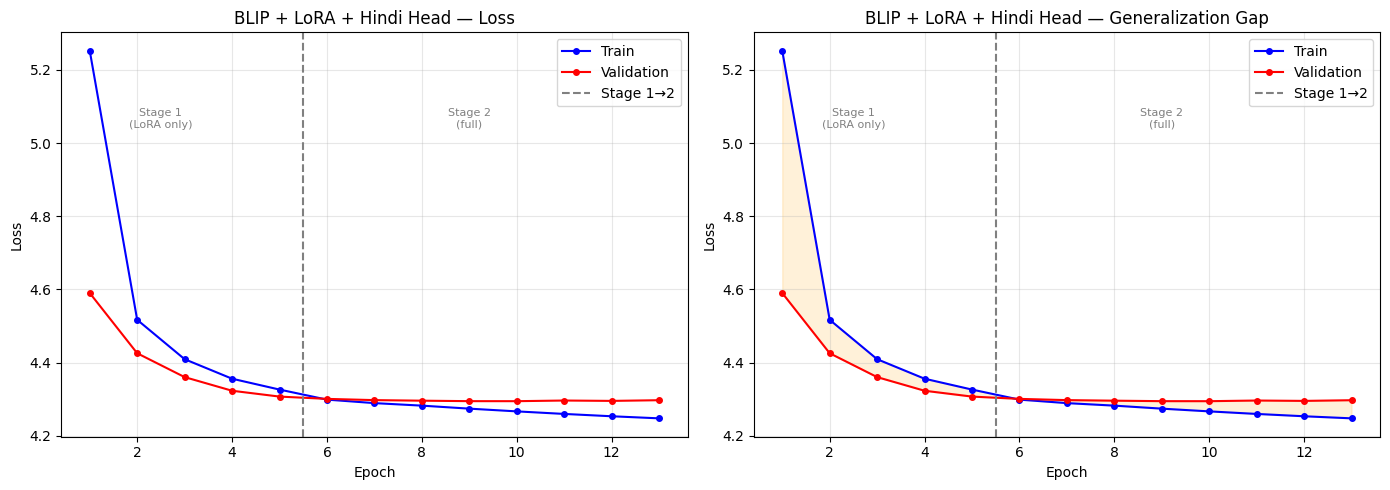

Saved: /content/drive/MyDrive/blip_lora_v2_checkpoints/training_curves.png


In [ ]:
# ============================================================
# CELL 11 — Training Curves
# ============================================================
STAGE1_EPOCHS = 5  # add this if you get a NameError
fig, axes    = plt.subplots(1, 2, figsize=(14, 5))
ep_range     = range(1, len(history['train_loss']) + 1)
boundary     = STAGE1_EPOCHS

for ax, title in zip(axes, ['Loss', 'Generalization Gap']):
    ax.plot(ep_range, history['train_loss'], 'b-o', ms=4, label='Train')
    ax.plot(ep_range, history['val_loss'],   'r-o', ms=4, label='Validation')
    ax.axvline(x=boundary + 0.5, color='gray', ls='--', lw=1.5, label='Stage 1→2')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'BLIP + LoRA + Hindi Head — {title}')
    ax.legend(); ax.grid(True, alpha=0.3)
    ymax = max(history['train_loss'] + history['val_loss'])
    ax.text(boundary/2, ymax*0.96, 'Stage 1\n(LoRA only)',
            ha='center', fontsize=8, color='gray')
    if len(history['train_loss']) > boundary:
        mid = boundary + (len(history['train_loss']) - boundary) / 2
        ax.text(mid, ymax*0.96, 'Stage 2\n(full)',
                ha='center', fontsize=8, color='gray')

if axes[1]:
    axes[1].fill_between(ep_range, history['train_loss'], history['val_loss'],
                         alpha=0.15, color='orange')

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_path}")



In [ ]:
# FIXED Cell 12 — load without PeftModel since checkpoint is merged weights

if USE_GPU: torch.cuda.empty_cache()

best_dir       = os.path.join(CHECKPOINT_DIR, 'stage2_best')
best_head_path = os.path.join(CHECKPOINT_DIR, 'stage2_best_head.pt')
latest_path    = os.path.join(CHECKPOINT_DIR, 'stage2_latest.pt')

# Since model was saved via save_pretrained after merge_and_unload,
# it's a plain BlipForConditionalGeneration — load directly, no PeftModel
print("Loading model from checkpoint...")
model = BlipForConditionalGeneration.from_pretrained(best_dir).to(device)
processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
model.eval()
print("✅ Model loaded.")

# Reload Hindi head
if os.path.exists(best_head_path):
    hindi_head.load_state_dict(torch.load(best_head_path, map_location=device))
    hindi_head.eval()
    print("✅ Hindi head loaded.")

# Sanity check
print("\n── Sanity check (3 images) ──")
for img_name in random.sample(test_imgs, 3):
    cap = generate_caption_hindi(model, processor, os.path.join(IMAGES_DIR, img_name))
    ref = all_captions.get(img_name, [''])[0]
    print(f"  Gen: {cap}")
    print(f"  Ref: {ref}\n")

print("\nComputing BLEU on 500 images...\n")
bleu_scores = compute_bleu_scores_hindi(
    model, processor, test_imgs, all_captions,
    IMAGES_DIR, num_beams=10, max_samples=500
)

print("\n" + "="*60)
print("  BLEU SCORES — BLIP + LoRA + Hindi Head v2")
print("="*60)
for k, v in bleu_scores.items():
    if k != 'num_evaluated':
        print(f"  {k}: {v:.4f}")
print(f"  Evaluated on: {bleu_scores.get('num_evaluated',0)} images")
print("="*60)

all_results = [
    ("CNN+LSTM baseline (sem 1)",          0.246,  0.027),
    ("CNN+Attention (sem 1)",              0.427,  0.068),
    ("CNN+Transformer (sem 1)",            0.306,  0.049),
    ("Hybrid TF greedy (sem 2)",           0.4782, 0.1126),
    ("Hybrid TF beam search (sem 2)",      0.5042, 0.1333),
    ("BLIP+LoRA+Hindi Head (proposed)",
     bleu_scores.get('BLEU-1',0),
     bleu_scores.get('BLEU-4',0)),
]
print(f"\n  {'Model':<42} {'BLEU-1':>8} {'BLEU-4':>8}")
print("  " + "-"*58)
for i, (name, b1, b4) in enumerate(all_results):
    tag = "  ⭐" if i == len(all_results)-1 else ""
    print(f"  {name:<42} {b1:>8.4f} {b4:>8.4f}{tag}")

Loading model from checkpoint...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model loaded.
✅ Hindi head loaded.

── Sanity check (3 images) ──
  Gen: तसवीर म खिलाडी खल रह ह
  Ref: पुरुष फील्ड हॉकी खेल रहे हैं नीली छड़ी के साथ सोने की छड़ी के साथ

  Gen: तसवीर म लोगो का समह पारटी म आदमी
  Ref: प्रोम पोशाक में इकट्ठा करने के लिए किशोरों का समूह

  Gen: तसवीर म कतता पर खलता ह
  Ref: काला कुत्ता घास पर सफेद कुत्ता काटता है


Computing BLEU on 500 images...



Computing BLEU:   0%|          | 0/500 [00:00<?, ?it/s]


  BLEU SCORES — BLIP + LoRA + Hindi Head v2
  BLEU-1: 0.1505
  BLEU-2: 0.0473
  BLEU-3: 0.0188
  BLEU-4: 0.0083
  Evaluated on: 500 images

  Model                                        BLEU-1   BLEU-4
  ----------------------------------------------------------
  CNN+LSTM baseline (sem 1)                    0.2460   0.0270
  CNN+Attention (sem 1)                        0.4270   0.0680
  CNN+Transformer (sem 1)                      0.3060   0.0490
  Hybrid TF greedy (sem 2)                     0.4782   0.1126
  Hybrid TF beam search (sem 2)                0.5042   0.1333
  BLIP+LoRA+Hindi Head (proposed)              0.1505   0.0083  ⭐


/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Glyph 2368 (\N{DEVANAGARI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21994/2570698919.py:25: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_lay

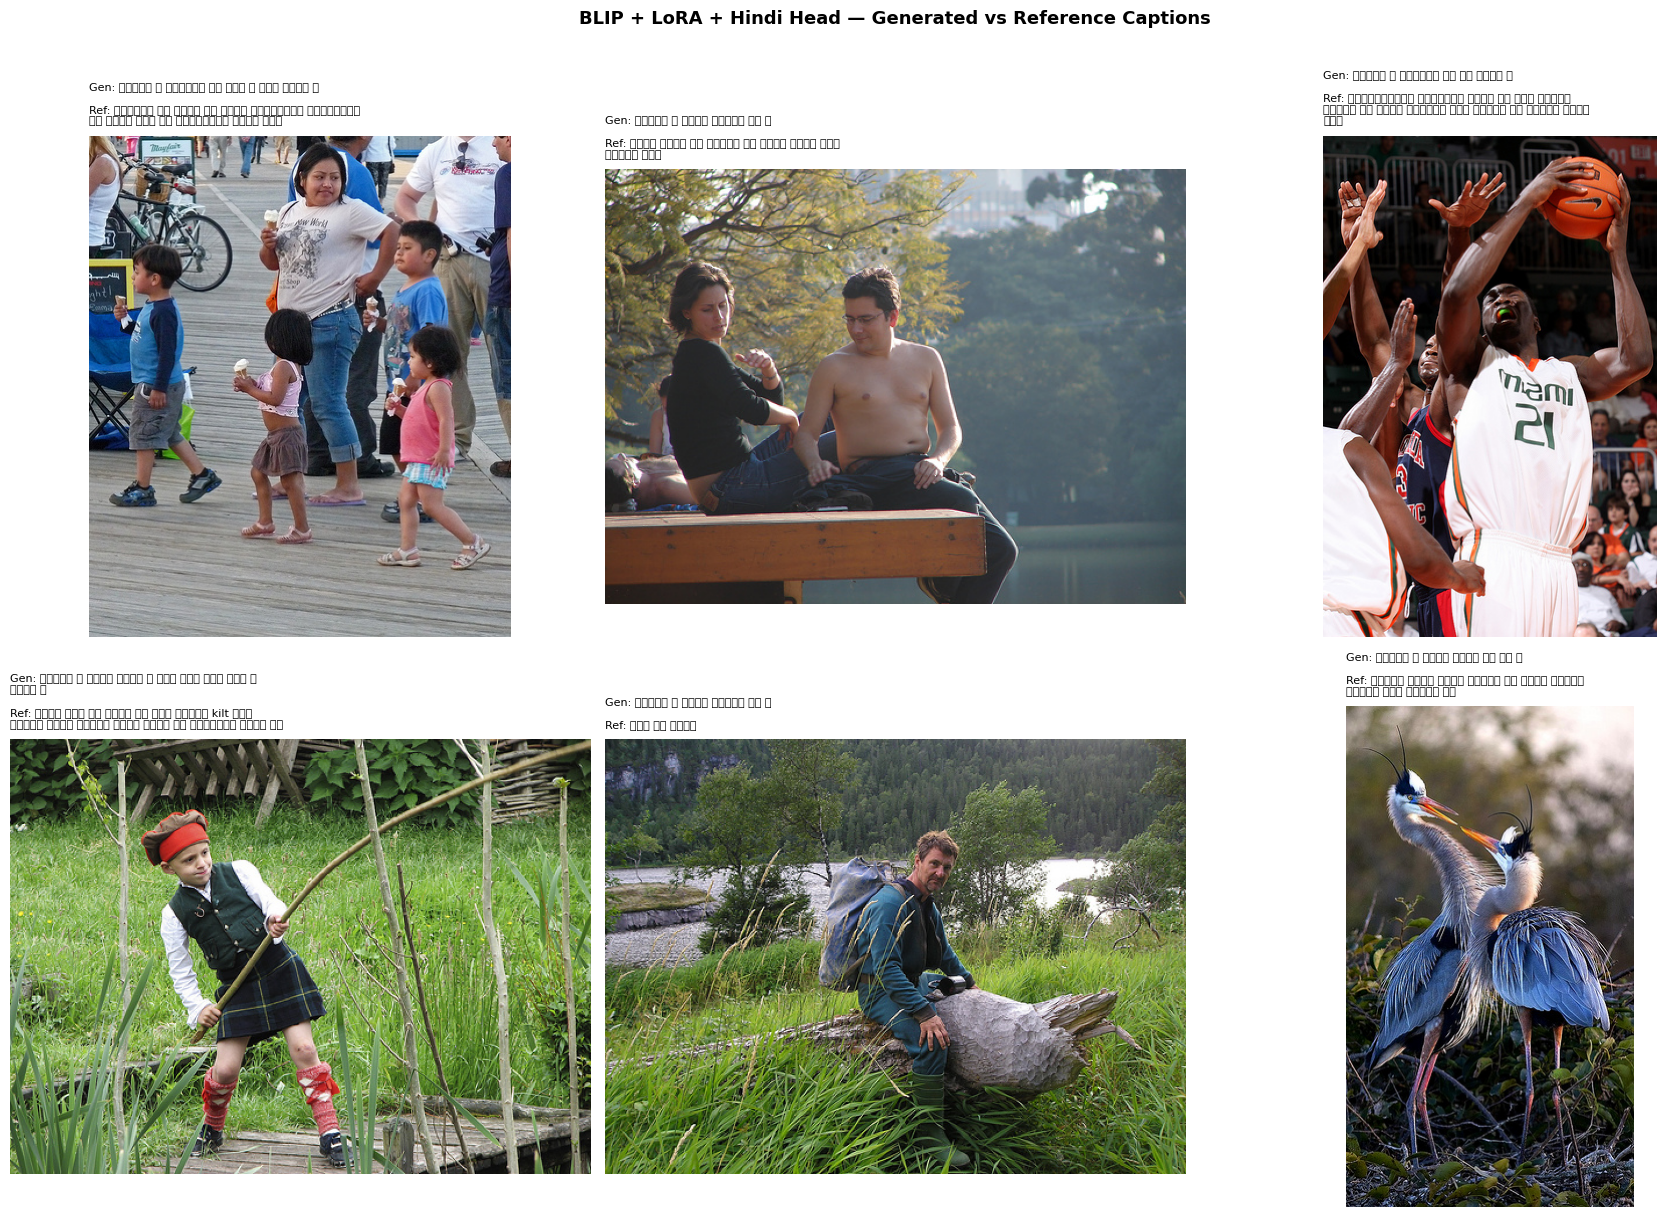

Saved: /content/drive/MyDrive/blip_lora_v2_checkpoints/qualitative_examples.png


In [ ]:
# ============================================================
# CELL 13 — Qualitative Examples
# ============================================================

if USE_GPU: torch.cuda.empty_cache()

sample_imgs = random.sample(test_imgs, min(6, len(test_imgs)))
fig, axes   = plt.subplots(2, 3, figsize=(18, 12))
axes        = axes.flatten()

for i, img_name in enumerate(sample_imgs):
    img_path  = os.path.join(IMAGES_DIR, img_name)
    generated = generate_caption_hindi(model, processor, img_path, num_beams=5)
    refs      = all_captions.get(img_name, [])
    ref_text  = refs[0].strip() if refs else 'N/A'

    axes[i].imshow(mpimg.imread(img_path))
    axes[i].axis('off')
    gen_w = '\n'.join(textwrap.wrap(f"Gen: {generated}", 45))
    ref_w = '\n'.join(textwrap.wrap(f"Ref: {ref_text}",  45))
    axes[i].set_title(f"{gen_w}\n\n{ref_w}", fontsize=8, loc='left', pad=8)

plt.suptitle("BLIP + LoRA + Hindi Head — Generated vs Reference Captions",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
qual_path = os.path.join(CHECKPOINT_DIR, 'qualitative_examples.png')
plt.savefig(qual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {qual_path}")

In [ ]:
# ============================================================
# CELL 14 — Save Everything to Drive
# ============================================================

results = {
    'model':        'Salesforce/blip-image-captioning-base + LoRA (r=16)',
    'custom_components': {
        'lora': 'rank=16, alpha=32, target=query+value, dropout=0.1',
        'hindi_head': '768→LayerNorm→512→GELU→Dropout→LayerNorm→vocab',
    },
    'dataset':    'Flickr8k-Hindi',
    'training': {
        'stage1_epochs': STAGE1_EPOCHS, 'stage1_lr': STAGE1_LR,
        'stage2_max_epochs': STAGE2_EPOCHS,
        'vision_lr': VISION_LR, 'decoder_lr': DECODER_LR,
        'batch_size': BATCH_SIZE,
        'total_epochs': len(history['train_loss']),
        'best_val_loss': min(history['val_loss']),
    },
    'bleu_scores':      bleu_scores,
    'training_history': history,
}

results_path = os.path.join(CHECKPOINT_DIR, 'final_results.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

history_path = os.path.join(CHECKPOINT_DIR, 'history.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(history, f)

print(f"✅ Saved: {results_path}")
print(f"✅ Saved: {history_path}")
print(f"\nFinal: BLEU-1={bleu_scores.get('BLEU-1',0):.4f} | "
      f"BLEU-4={bleu_scores.get('BLEU-4',0):.4f}")



NameError: name 'STAGE1_LR' is not defined

In [ ]:
# ============================================================
# CELL 15 — Live Caption: Upload Any Image
# ============================================================

from google.colab import files

print("Upload any image to generate a Hindi caption:")
uploaded = files.upload()

for filename in uploaded.keys():
    caption = generate_caption(model, processor, filename, num_beams=5)
    img     = Image.open(filename)
    plt.figure(figsize=(6, 6))
    plt.imshow(img); plt.axis('off')
    plt.title(f"Generated Hindi Caption:\n{caption}", fontsize=12, pad=10)
    plt.tight_layout(); plt.show()
    print(f"Image:   {filename}")
    print(f"Caption: {caption}")


In [ ]:
# DIAGNOSTIC — run before anything else
print("=== SAMPLE CAPTIONS ===")
for img_name in random.sample(test_imgs, 10):
    cap = generate_caption_hindi(model, processor,
                                  os.path.join(IMAGES_DIR, img_name))
    ref = all_captions.get(img_name, [''])[0]
    print(f"Gen: '{cap}'")
    print(f"Ref: '{ref}'")
    print(f"Gen length: {len(cap.split())} words")
    print()

# Check if the prompt prefix is eating into the BLEU evaluation
print("\n=== BLEU WITH PREFIX STRIPPED ===")
# The prefix 'इस तस्वीर में' appears in every generated caption
# If BLEU refs don't have it, that kills scores
# Check if refs contain the prefix
sample_refs = []
for img_name in list(all_captions.keys())[:5]:
    for cap in all_captions[img_name]:
        sample_refs.append(cap)

prefix_in_refs = sum(1 for r in sample_refs if 'इस तस्वीर में' in r)
print(f"Refs containing prefix 'इस तस्वीर में': {prefix_in_refs}/{len(sample_refs)}")
print(f"\nSample refs:")
for r in sample_refs[:3]:
    print(f"  '{r}'")

=== SAMPLE CAPTIONS ===
Gen: 'तसवीर म लडकी बालो वाली महिला खलती ह'
Ref: 'सभी गुलाबी में बच्चा पास में इमारतों के साथ घुमक्कड़ के पास प्रस्तुत कर रहा है'
Gen length: 8 words

Gen: 'तसवीर म लडका पानी क माधयम स ह'
Ref: 'झील में खेलता लड़का'
Gen length: 8 words

Gen: 'तसवीर म कततो का समह करता ह'
Ref: 'कुत्ते ने बर्फ से होकर दौड़ लगाई'
Gen length: 7 words

Gen: 'तसवीर म काला कतता पानी म खडा ह'
Ref: 'काला कुत्ता पानी में खेलता है'
Gen length: 8 words

Gen: 'तसवीर म पील रग की सवारी करता ह'
Ref: 'नारंगी जाति की कार में लोग'
Gen length: 8 words

Gen: 'तसवीर म लडका लाल बालो वाला खलता ह'
Ref: 'लड़का प्लास्टिक का बल्ला घुमाता है'
Gen length: 8 words

Gen: 'तसवीर म लाल शरट म लडका की सवारी करता ह'
Ref: 'लाल हेलमेट पहने छोटा लड़का अपनी साइकिल को पैटर्न वाले रास्ते पर चलाता है'
Gen length: 10 words

Gen: 'तसवीर म काला कतता अपन मह म खलता ह'
Ref: 'काले और सफेद कुत्ते को मिडेयर में खिलौना पकड़ाता है'
Gen length: 9 words

Gen: 'तसवीर म लडका क साथ खलता ह'
Ref: 'बच्चा खेल के मैदान पर खिलौने के साथ खेलता है'

In [ ]:
# FIXED evaluation — strip prefix + recompute BLEU

def generate_caption_hindi(model, processor, image_path,
                            num_beams=10, max_length=64):
    model.eval()
    try:
        image = Image.open(image_path).convert('RGB')
    except:
        return ""

    inputs = processor(
        images=image,
        text="इस तस्वीर में",
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            pixel_values=inputs['pixel_values'],
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            num_beams=num_beams,
            max_length=max_length,
            early_stopping=True,
            no_repeat_ngram_size=2,
            length_penalty=1.5,      # encourage longer captions
            min_length=8,            # force minimum length
        )

    caption = processor.decode(out[0], skip_special_tokens=True).strip()

    # Strip the prompt prefix from generated caption
    for prefix in ["इस तस्वीर में ", "तसवीर म ", "इस तस्वीर में"]:
        if caption.startswith(prefix):
            caption = caption[len(prefix):].strip()

    return caption


# Quick check first
print("Captions after prefix stripping:")
for img_name in random.sample(test_imgs, 5):
    cap = generate_caption_hindi(model, processor,
                                  os.path.join(IMAGES_DIR, img_name))
    ref = all_captions.get(img_name, [''])[0]
    print(f"  Gen: {cap}")
    print(f"  Ref: {ref}\n")

# Now recompute BLEU
print("Computing BLEU on 500 images...\n")
bleu_scores = compute_bleu_scores_hindi(
    model, processor, test_imgs, all_captions,
    IMAGES_DIR, num_beams=10, max_samples=500
)

print("\n" + "="*60)
print("  BLEU SCORES — BLIP + LoRA + Hindi Head (Fixed)")
print("="*60)
for k, v in bleu_scores.items():
    if k != 'num_evaluated':
        print(f"  {k}: {v:.4f}")
print(f"  Evaluated on: {bleu_scores.get('num_evaluated',0)} images")
print("="*60)

all_results = [
    ("CNN+LSTM baseline (sem 1)",          0.246,  0.027),
    ("CNN+Attention (sem 1)",              0.427,  0.068),
    ("CNN+Transformer (sem 1)",            0.306,  0.049),
    ("Hybrid TF greedy (sem 2)",           0.4782, 0.1126),
    ("Hybrid TF beam search (sem 2)",      0.5042, 0.1333),
    ("BLIP+LoRA+Hindi Head (proposed)",
     bleu_scores.get('BLEU-1',0),
     bleu_scores.get('BLEU-4',0)),
]
print(f"\n  {'Model':<42} {'BLEU-1':>8} {'BLEU-4':>8}")
print("  " + "-"*58)
for i, (name, b1, b4) in enumerate(all_results):
    tag = "  ⭐" if i == len(all_results)-1 else ""
    print(f"  {name:<42} {b1:>8.4f} {b4:>8.4f}{tag}")

Captions after prefix stripping:
  Gen: कतता क मदान म चल रहा ह
  Ref: सफेद और भूरे रंग का कुत्ता हवा के माध्यम से छलांग लगा रहा है

  Gen: भर रग का कतता अपन मह म खल रहा ह
  Ref: भूरे रंग का पिल्ला धातु की पोस्ट में सूँघ रहा है जो जमीन में फंस गया है

  Gen: लडका सकटबोरड की सवारी करता ह
  Ref: बच्चा साइकिल चलाता है जबकि भीड़ देखता है

  Gen: लडका की सवारी करता ह
  Ref: छोटी बच्ची बर्फ से सराबोर है

  Gen: मसकराती महिला काल रग की शरी क साथ खडी ह
  Ref: गोरे बालों वाली लड़की अपनी काली छतरी के नीचे से मंदमंद मुस्कान प्रदान करती है

Computing BLEU on 500 images...



Computing BLEU:   0%|          | 0/500 [00:00<?, ?it/s]


  BLEU SCORES — BLIP + LoRA + Hindi Head (Fixed)
  BLEU-1: 0.1884
  BLEU-2: 0.0555
  BLEU-3: 0.0216
  BLEU-4: 0.0106
  Evaluated on: 500 images

  Model                                        BLEU-1   BLEU-4
  ----------------------------------------------------------
  CNN+LSTM baseline (sem 1)                    0.2460   0.0270
  CNN+Attention (sem 1)                        0.4270   0.0680
  CNN+Transformer (sem 1)                      0.3060   0.0490
  Hybrid TF greedy (sem 2)                     0.4782   0.1126
  Hybrid TF beam search (sem 2)                0.5042   0.1333
  BLIP+LoRA+Hindi Head (proposed)              0.1884   0.0106  ⭐
